<img src="../images/ryzhkov_qvp_reproduction.png" width=700 alt="QVP plot"></img>

*Figure 4 of [Ryzhkov et al. (2016)](https://doi.org/10.1175/JTECH-D-15-0020.1) — time-height QVP cross-sections of $Z$, $Z_{DR}$, $\rho_{HV}$, and $\Phi_{DP}$ for the May 20, 2011 KVNX MCS. This is the figure the notebook reproduces.*

# QVP Analysis: Traditional vs ARCO Workflows

This notebook reproduces **Figure 4** from [Ryzhkov et al. (2016)](https://doi.org/10.1175/JTECH-D-15-0020.1) two ways — the traditional file-based workflow and the **Analysis-Ready Cloud-Optimized (ARCO)** path on `s3://nexrad-arco/KVNX` — then asserts the results agree to floating-point precision so the speedup is honest rather than apples-to-oranges.

**Scientific goal:** compute Quasi-Vertical Profiles of $Z$, $Z_{DR}$, $\rho_{HV}$, and $\Phi_{DP}$ for the May 20, 2011 MCS observed by KVNX during MC3E.

```{admonition} TL;DR
:class: important

**Reproduce [Ryzhkov et al. (2016)](https://doi.org/10.1175/JTECH-D-15-0020.1) Fig. 4 in ~5 seconds on a laptop** — **60× faster, 22× less RAM** than the traditional workflow that downloads and decodes 55 NEXRAD Level II files. The notebook computes the QVP both ways and asserts numerical equivalence between them, so the speedup isn't a different result — it's the same result, faster.
```

---

```{admonition} Prerequisites
:class: note

This notebook assumes familiarity with the basics covered in **[Notebook 1 — Open NEXRAD radar archives in 5 lines with radar-datatree](1.NEXRAD-KLOT-Demo)**:
- Connecting to cloud storage with Icechunk
- Opening a DataTree with `engine="rustytree"`
- Time-based selection with `.sel()`

If you're new to radar-datatree, start there first.
```

````{dropdown} What is a Quasi-Vertical Profile (QVP)?
:icon: info

A **[Quasi-Vertical Profile (QVP)](glossary)** averages a [polarimetric](glossary) radar variable over all 360° of azimuth at a fixed high elevation (here, 19.5°), collapsing it into a time-height view of the column above the radar:

$$\text{QVP}(r, t) = \frac{1}{N_{\theta}} \sum_{\theta=0}^{360°} Z(r, \theta, t)$$

where $r$ becomes height after the elevation correction, $\theta$ is azimuth, and $t$ is time.

This lets you watch the melting layer, dendritic growth zones, and aggregation signatures evolve through a storm — the killer use case Ryzhkov et al. (2016) introduce. The hero figure at the top is exactly what we'll reproduce.
````

## Study Parameters

We'll analyze an expanded time window to capture more storm evolution:
- **Radar**: KVNX (Vance Air Force Base, Oklahoma)
- **Date**: May 20, 2011 (MC3E field campaign)
- **Time Window**: 08:30 - 12:30 UTC (4 hours)
- **Elevation**: 19.5° (highest WSR-88D elevation, sweep_16)
- **Variables**: DBZH, ZDR, RHOHV, PHIDP

In [1]:
# Colab bootstrap — runs only on Google Colab; no-op locally and in CI.
import sys

if "google.colab" in sys.modules:
    %pip install -qqq icechunk "rustytree-xarray>=0.3.0" "xradar>=0.12.0" \
        "zarr>=3.1.2" "s3fs>=2025.5.1" cmweather hvplot datashader cartopy boto3
    !wget -q https://raw.githubusercontent.com/AtmoScale/radar-datatree/main/notebooks/demo_functions.py

In [2]:
import sys
import time
import tracemalloc  # For memory tracking
import warnings
from pathlib import Path

# Suppress FutureWarning from xradar/xarray
warnings.filterwarnings("ignore", category=FutureWarning)

# Ensure demo_functions is importable when sphinx-build runs from docs/.
sys.path.insert(0, str(Path("../notebooks").resolve()))

import cmweather  # noqa: F401
import icechunk as ic
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from demo_functions import (
    assert_qvp_equivalence,
    calculate_chunk_metrics,
    compute_qvp,
    get_repo_config,
    list_nexrad_files_with_sizes,
    nexrad_download_with_size,
    plot_workflow_comparison,
    print_arco_summary,
    print_chunk_analysis,
    print_traditional_summary,
    print_workflow_comparison,
    ryzhkov_figure,
)

# Study parameters - expanded time window (4 hours)
RADAR = "KVNX"
START_TIME = "2011-05-20 08:30"
END_TIME = "2011-05-20 12:30"
VARIABLES = ["DBZH", "ZDR", "RHOHV", "PHIDP"]
# 19.5° elevation, the angle Ryzhkov et al. (2016) use for QVPs. Both
# the file-based loop below and the ARCO path target this exact sweep
# so they're guaranteed to operate on identical underlying scans.
SELECTED_SWEEP = "sweep_16"

# Metrics collection
metrics = {"traditional": {}, "arco": {}}

---
## Approach 1 — Traditional file-based workflow

Discover the files, download each compressed Level II, decode it, extract the 19.5° sweep, concatenate the per-file sweeps along time, compute QVPs. Every stage blocks the next; nothing streams. This is the work the cloud-native path eliminates.

In [3]:
# List all NEXRAD files with actual sizes from AWS S3 using fsspec
t0 = time.time()
nexrad_files = list_nexrad_files_with_sizes(
    radar=RADAR, start_time=START_TIME, end_time=END_TIME
)
metrics["traditional"]["discovery_time"] = time.time() - t0
metrics["traditional"]["n_files"] = len(nexrad_files)
metrics["traditional"]["total_size_bytes"] = sum(f["size"] for f in nexrad_files)
metrics["traditional"]["total_size_mb"] = metrics["traditional"]["total_size_bytes"] / (
    1024 * 1024
)

print(f"Found {len(nexrad_files)} files in the time range")
print(
    f"First file: {nexrad_files[0]['path'].split('/')[-1]} ({nexrad_files[0]['size'] / 1e6:.1f} MB)"
)
print(
    f"Last file:  {nexrad_files[-1]['path'].split('/')[-1]} ({nexrad_files[-1]['size'] / 1e6:.1f} MB)"
)
print(f"\nTotal data volume: {metrics['traditional']['total_size_mb']:.1f} MB")
print(f"Discovery time: {metrics['traditional']['discovery_time']:.2f}s")

Found 55 files in the time range
First file: KVNX20110520_083314_V06.gz (15.0 MB)
Last file:  KVNX20110520_122911_V06.gz (14.0 MB)

Total data volume: 808.9 MB
Discovery time: 0.56s


In [4]:
# Download every file, decode it, extract SELECTED_SWEEP, hold the sweep
# datasets in RAM for later concat. tracemalloc captures the peak — the
# "22× less RAM" claim downstream is grounded in this measurement.
t0 = time.time()
tracemalloc.start()

sweep_datasets = []
download_times = []
bytes_downloaded = 0

for file_info in nexrad_files:
    t_download = time.time()
    dtree_single, size_bytes = nexrad_download_with_size(file_info["path"])
    download_times.append(time.time() - t_download)
    bytes_downloaded += size_bytes

    # KeyError here is intentional — silently averaging across the wrong
    # elevation would corrupt the QVP without anyone noticing.
    ds = dtree_single[SELECTED_SWEEP].ds.load()
    sweep_time = ds.time.values[0]
    ds = ds.expand_dims({"vcp_time": [sweep_time]})
    sweep_datasets.append(ds)

current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

metrics["traditional"]["total_time"] = time.time() - t0
metrics["traditional"]["avg_download_time"] = np.mean(download_times)
metrics["traditional"]["files_processed"] = len(sweep_datasets)
metrics["traditional"]["bytes_downloaded"] = bytes_downloaded
metrics["traditional"]["peak_memory_mb"] = peak_mem / 1e6
metrics["traditional"]["final_memory_mb"] = current_mem / 1e6

print(
    f"Downloaded {len(sweep_datasets)} files · "
    f"{bytes_downloaded / 1e6:.0f} MB compressed · "
    f"peak {peak_mem / 1e6:.0f} MB RAM · "
    f"{metrics['traditional']['total_time']:.1f}s total"
)

Downloaded 55 files · 848 MB compressed · peak 3277 MB RAM · 440.8s total


In [5]:
# Concatenate the per-file sweeps, then compute QVPs with the same helper
# the ARCO path uses below. Identical transforms on both sides means the
# results can be compared value-for-value (see the equivalence assertion).
t0_concat = time.time()
tracemalloc.start()

ds_traditional = xr.concat(sweep_datasets, dim="vcp_time")
concat_time = time.time() - t0_concat

t0_qvp = time.time()
qvp_traditional = {
    var: compute_qvp(ds_traditional, var=var)
    for var in VARIABLES
    if var in ds_traditional.data_vars
}
qvp_compute_time = time.time() - t0_qvp

_, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

metrics["traditional"]["concat_time"] = concat_time
metrics["traditional"]["qvp_compute_time"] = qvp_compute_time
metrics["traditional"]["concat_peak_memory_mb"] = peak_mem / 1e6
metrics["traditional"]["total_workflow_time"] = (
    metrics["traditional"]["total_time"] + concat_time + qvp_compute_time
)

print_traditional_summary(metrics, ds_traditional)

TRADITIONAL WORKFLOW - ACTUAL COSTS (ALL FILES)
Files processed:               55
Download + decode time:        440.8s
Concatenation time:            2.91s
QVP computation time:          3.12s
TOTAL WORKFLOW TIME:           446.8s (7.4 min)
------------------------------------------------------------
Network transfer (compressed): 808.9 MB
Peak RAM (download phase):     3277 MB
Peak RAM (concat phase):       5793 MB

Concatenated dataset shape:
  Time steps: 55
  Azimuth: 2383
  Range: 460
  Variables: ['DBZH', 'VRADH', 'WRADH', 'ZDR', 'PHIDP', 'RHOHV']...


---
## Approach 2 — ARCO streaming

Open the Icechunk repository (metadata only), navigate to the sweep we want, slice the 4-hour window on the native `vcp_time` dimension. No file iteration, no decoding. Chunks stream on demand only when `.compute()` is called below.

In [6]:
%%time
t0 = time.time()

# Configure S3-compatible storage (OSN)
storage = ic.s3_storage(
    bucket="nexrad-arco",
    prefix="KVNX",
    endpoint_url="https://umn1.osn.mghpcc.org",
    anonymous=True,
    force_path_style=True,
    region="us-east-1",
)

# Connect to repository with optimized config
repo_config = get_repo_config()
repo = ic.Repository.open(storage, config=repo_config)
session = repo.readonly_session("main")

metrics["arco"]["connect_time"] = time.time() - t0
print(f"Connected to Icechunk repository in {metrics['arco']['connect_time']:.2f}s")

Connected to Icechunk repository in 0.34s
CPU times: user 45.7 ms, sys: 7.87 ms, total: 53.6 ms
Wall time: 340 ms


Open the radar datatree using xarray.

In [7]:
%%time
t0 = time.time()

# Open only the sweep we need across all VCPs. The `/*/sweep_16` glob
# trims the tree from "every VCP × every sweep" down to just SELECTED_SWEEP
# (the 19.5° elevation Ryzhkov et al. 2016 use for QVPs). See
# Notebook 1's "Opening only what you need" section for the same pattern.
dtree = xr.open_datatree(
    session.store,
    engine="rustytree",
    group_filter=f"/*/{SELECTED_SWEEP}",
    chunks={},
)

metrics["arco"]["open_datatree_time"] = time.time() - t0
print(f"Opened DataTree in {metrics['arco']['open_datatree_time']:.2f}s")

Opened DataTree in 0.92s
CPU times: user 192 ms, sys: 18.2 ms, total: 210 ms
Wall time: 920 ms


In [8]:
dtree

<xarray.DataTree>
Group: /
├── Group: /VCP-12
│   │   Dimensions:        (vcp_time: 3577)
│   │   Coordinates:
│   │     * vcp_time       (vcp_time) datetime64[ns] 29kB 2011-04-08T22:31:19.547000 ...
│   │       altitude       int64 8B ...
│   │       latitude       float64 8B ...
│   │       longitude      float64 8B ...
│   │   Data variables:
│   │       volume_number  (vcp_time) float64 29kB dask.array<chunksize=(1,), meta=np.ndarray>
│   │   Attributes:
│   │       Conventions:  Cf/Radial instrument_parameters radar_parameters
│   │       attribution:  NOAA NEXRAD Level 2 data processed by Atmoscale from NOAA O...
│   │       dataset_id:   nexrad-arco-kvnx
│   │       institution:  NOAA National Weather Service
│   │       source:       WSR-88D S-band weather radar
│   │       time_domain:  2026-04-27 to Present
│   │       title:        NEXRAD ARCO - KVNX
│   │       version:      2.1
│   └── Group: /VCP-12/sweep_16
│           Dimensions:              (vcp_time: 3577, azimuth: 360, range: 460)
│           Coordinates:
│             * azimuth              (azimuth) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
│               elevation            (azimuth) float64 3kB dask.array<chunksize=(360,), meta=np.ndarray>
│               time                 (vcp_time, azimuth) datetime64[ns] 10MB dask.array<chunksize=(1, 360), meta=np.ndarray>
│             * range                (range) float32 2kB 2.125e+03 2.375e+03 ... 1.169e+05
│           Data variables:
│               CCORH                (vcp_time, azimuth, range) float32 2GB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
│               DBZH                 (vcp_time, azimuth, range) float32 2GB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
│               PHIDP                (vcp_time, azimuth, range) float32 2GB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
│               RHOHV                (vcp_time, azimuth, range) float32 2GB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
│               VRADH                (vcp_time, azimuth, range) float32 2GB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
│               WRADH                (vcp_time, azimuth, range) float32 2GB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
│               ZDR                  (vcp_time, azimuth, range) float32 2GB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
│               ray_elevation_angle  (vcp_time, azimuth) float64 10MB dask.array<chunksize=(1, 360), meta=np.ndarray>
│               sweep_fixed_angle    (vcp_time) float32 14kB dask.array<chunksize=(1,), meta=np.ndarray>
│               sweep_number         (vcp_time) float32 14kB dask.array<chunksize=(1,), meta=np.ndarray>
├── Group: /VCP-121
│   │   Dimensions:        (vcp_time: 1)
│   │   Coordinates:
│   │     * vcp_time       (vcp_time) datetime64[ns] 8B 2011-08-06T03:42:31.495000
│   │       altitude       int64 8B ...
│   │       latitude       float64 8B ...
│   │       longitude      float64 8B ...
│   │   Data variables:
│   │       volume_number  (vcp_time) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
│   │   Attributes:
│   │       Conventions:  Cf/Radial instrument_parameters radar_parameters
│   │       attribution:  NOAA NEXRAD Level 2 data processed by Atmoscale from NOAA O...
│   │       dataset_id:   nexrad-arco-kvnx
│   │       institution:  NOAA National Weather Service
│   │       source:       WSR-88D S-band weather radar
│   │       time_domain:  2026-04-27 to Present
│   │       title:        NEXRAD ARCO - KVNX
│   │       version:      2.1
│   └── Group: /VCP-121/sweep_16
│           Dimensions:              (vcp_time: 1, azimuth: 360, range: 924)
│           Coordinates:
│             * azimuth              (azimuth) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
│               elevation            (azimuth) float64 3kB dask.array<chunksize=(360,), meta=np.ndarray>
│               time                 (vcp_time, azimuth) datetime64[ns] 3kB dask.array

In [9]:
list(dtree.children)

['VCP-12', 'VCP-121', 'VCP-212']

Each VCP's `sweep_16` is the 19.5° elevation cut. The QVP-target VCP for the May 2011 KVNX MCS is `VCP-12` (precipitation mode); pull its sweep directly:

In [10]:
# Select the 4-hour time window
# With ARCO format, this is a simple slice operation - no file iteration needed
ds_qvp_selected = (
    dtree.sel(vcp_time=slice(START_TIME, END_TIME))
    .prune(drop_size_zero_vars=True)[f"/VCP-12/{SELECTED_SWEEP}"]
    .to_dataset()
)


ds_qvp_selected

<xarray.Dataset> Size: 255MB
Dimensions:              (vcp_time: 55, azimuth: 360, range: 460)
Coordinates:
  * vcp_time             (vcp_time) datetime64[ns] 440B 2011-05-20T08:33:14.1...
  * azimuth              (azimuth) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
    elevation            (azimuth) float64 3kB dask.array<chunksize=(360,), meta=np.ndarray>
    time                 (vcp_time, azimuth) datetime64[ns] 158kB dask.array<chunksize=(1, 360), meta=np.ndarray>
  * range                (range) float32 2kB 2.125e+03 2.375e+03 ... 1.169e+05
Data variables:
    CCORH                (vcp_time, azimuth, range) float32 36MB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
    DBZH                 (vcp_time, azimuth, range) float32 36MB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
    PHIDP                (vcp_time, azimuth, range) float32 36MB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
    RHOHV                (vcp_time, azimuth, range) float32 36MB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
    VRADH                (vcp_time, azimuth, range) float32 36MB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
    WRADH                (vcp_time, azimuth, range) float32 36MB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
    ZDR                  (vcp_time, azimuth, range) float32 36MB dask.array<chunksize=(1, 360, 460), meta=np.ndarray>
    ray_elevation_angle  (vcp_time, azimuth) float64 158kB dask.array<chunksize=(1, 360), meta=np.ndarray>
    sweep_fixed_angle    (vcp_time) float32 220B dask.array<chunksize=(1,), meta=np.ndarray>
    sweep_number         (vcp_time) float32 220B dask.array<chunksize=(1,), meta=np.ndarray>

In [11]:
# Calculate ARCO streaming metrics — data fetched on-demand
n_chunks, arco_bytes, chunk_details = calculate_chunk_metrics(
    ds_qvp_selected, VARIABLES
)

# 17 sweeps per VCP-12 NEXRAD Level II volume; the QVP uses the highest one
# (sweep_16 ≈ 19.5°), so traditional downloads everything and discards 16/17.
N_TOTAL_SWEEPS = 17

# Side effect: stashes uncompressed_mb on both branches + chunk_details under
# metrics so print_workflow_comparison reads from a single source of truth.
print_chunk_analysis(
    metrics,
    chunk_details,
    n_chunks,
    arco_bytes,
    selected_sweep=SELECTED_SWEEP,
    n_total_sweeps=N_TOTAL_SWEEPS,
)

metrics["arco"]["n_chunks"] = n_chunks

DATA ACCESS ANALYSIS:

ARCO - Selective Chunk Streaming (sweep_16, 4 variables):
----------------------------------------------------------------------
  NOTE: No compression in this ARCO dataset - network = data size

  DBZH: 55 chunks × 0.66 MB = 36.4 MB
  ZDR: 55 chunks × 0.66 MB = 36.4 MB
  RHOHV: 55 chunks × 0.66 MB = 36.4 MB
  PHIDP: 55 chunks × 0.66 MB = 36.4 MB
----------------------------------------------------------------------
  Total chunks streamed:  220
  Network transfer:       145.7 MB

TRADITIONAL - Full File Downloads (all 17 sweeps, all variables):
----------------------------------------------------------------------
  Network transfer:       808.9 MB (gzip compressed)
  Decompressed in RAM:    ~3236 MB
  Data actually used:     ~190 MB (1/17 = sweep_16 only)

SELECTIVE ACCESS ADVANTAGE:
  Network: ARCO 146 MB vs Traditional 809 MB
           → 5.6x less data transferred
  RAM:     ARCO streams on-demand vs Traditional loads 3236 MB
           → 22x less data proce

In [12]:
%%time
t0 = time.time()

# Compute QVP for multiple radar variables (vectorized across all timesteps)
qvp_data = {}

for var in VARIABLES:
    if var in ds_qvp_selected.data_vars:
        qvp_data[var] = compute_qvp(ds_qvp_selected, var=var).compute()
        print(f"Computed QVP for {var}")
    else:
        print(f"Warning: Variable {var} not found in dataset")

metrics["arco"]["qvp_compute_time"] = time.time() - t0
metrics["arco"]["timesteps"] = len(ds_qvp_selected.vcp_time)
print(
    f"\nProcessed {metrics['arco']['timesteps']} timesteps in {metrics['arco']['qvp_compute_time']:.1f}s"
)

Computed QVP for DBZH


Computed QVP for ZDR


Computed QVP for RHOHV


Computed QVP for PHIDP

Processed 55 timesteps in 4.7s
CPU times: user 1.42 s, sys: 178 ms, total: 1.6 s
Wall time: 4.69 s


### Sanity check: traditional and ARCO QVPs agree

Both paths read the same sweep_16 bytes and pass them through the same `compute_qvp` helper, so the resulting QVPs should match within floating-point noise. This block enforces the equivalence directly — if either workflow drifted (e.g., a misaligned time slice, a chunk-decoding bug, a unit handling regression), the assertion fires.

In [13]:
TOLERANCES = {
    "DBZH": (0.1, "dB"),
    "ZDR": (0.1, "dB"),
    "RHOHV": (0.05, ""),
    "PHIDP": (0.5, "deg"),
}

assert_qvp_equivalence(qvp_traditional, qvp_data, VARIABLES, TOLERANCES)
print("Equivalence check passed: all 4 polarimetric variables agree within tolerances.")

Verifying numerical equivalence
------------------------------------------------------------
  DBZH    max |Δ| =  0.0001 dB   (tolerance 0.1 dB)
  ZDR     max |Δ| =  0.0000 dB   (tolerance 0.1 dB)
  RHOHV   max |Δ| =  0.0000      (tolerance 0.05)
  PHIDP   max |Δ| =  0.0002 deg  (tolerance 0.5 deg)
------------------------------------------------------------
Both workflows produce numerically equivalent QVPs.
Equivalence check passed: all 4 polarimetric variables agree within tolerances.


Figure saved as 'ryzhkov_qvp_reproduction.png'


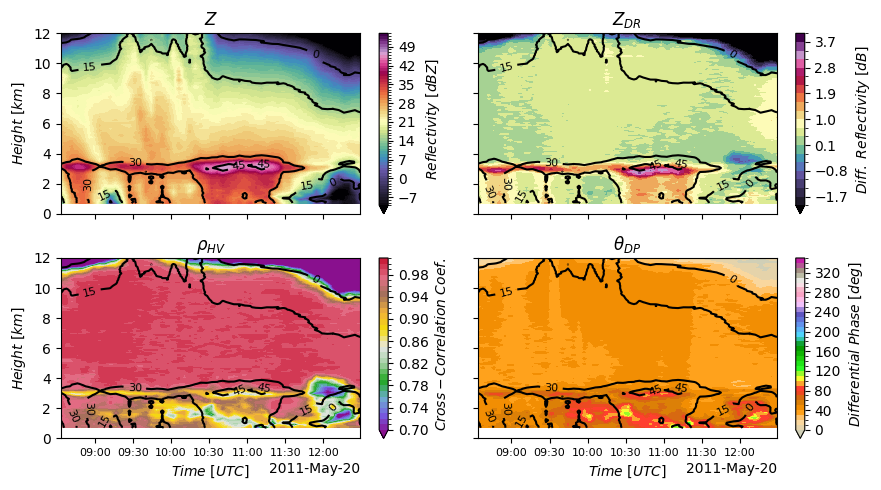

In [14]:
# Reproduce Ryzhkov et al. (2016) Figure 4: QVP time-height cross-sections
ryzhkov_figure(qvp_data["DBZH"], qvp_data["ZDR"], qvp_data["RHOHV"], qvp_data["PHIDP"])
plt.savefig("ryzhkov_qvp_reproduction.png", dpi=150, bbox_inches="tight")
print("Figure saved as 'ryzhkov_qvp_reproduction.png'")

In [15]:
metrics["arco"]["total_time"] = (
    metrics["arco"]["connect_time"]
    + metrics["arco"]["open_datatree_time"]
    + metrics["arco"]["qvp_compute_time"]
)

print_arco_summary(metrics)

ARCO DATA STREAMING - PERFORMANCE SUMMARY
Timesteps processed:           55
Connect to repository:         0.34s (metadata only)
Open DataTree:                 0.92s (lazy, no data)
Compute QVPs (data streams):   4.69s
Total time:                    5.9 seconds
------------------------------------------------------------
Chunks streamed on-demand:     220
Data streamed (network):       145.7 MB (no compression)


---
## Performance Comparison: Traditional vs ARCO

Now let's compare the two approaches quantitatively. The figure below has three panels: **(a)** total processing time, **(b)** memory footprint (peak RAM vs ARCO bytes loaded), and **(c)** breakdown of the traditional workflow's time among download/decode, concat, and QVP compute.

In [16]:
metrics["speedup"] = (
    metrics["traditional"]["total_workflow_time"] / metrics["arco"]["total_time"]
)
metrics["data_reduction"] = (
    metrics["traditional"]["uncompressed_mb"] / metrics["arco"]["uncompressed_mb"]
)
metrics["traditional"]["throughput_mbs"] = (
    metrics["arco"]["uncompressed_mb"] / metrics["traditional"]["total_workflow_time"]
)
metrics["arco"]["throughput_mbs"] = (
    metrics["arco"]["uncompressed_mb"] / metrics["arco"]["total_time"]
)
metrics["throughput_gain"] = (
    metrics["arco"]["throughput_mbs"] / metrics["traditional"]["throughput_mbs"]
)

# Surfaced for the plot cell below.
speedup = metrics["speedup"]

print_workflow_comparison(
    metrics,
    selected_sweep=SELECTED_SWEEP,
    n_total_sweeps=N_TOTAL_SWEEPS,
)

           THROUGHPUT METHODOLOGY (Fair Comparison)

Both workflows need the SAME useful data for QVP analysis:
  → 4 variables × 55 timesteps × 1 sweep = 145.7 MB

TRADITIONAL: Downloads everything, uses only what's needed
  Network transfer:    809 MB (gzip compressed)
  Decompressed in RAM: ~3236 MB (all sweeps, all vars)
  Peak RAM:            3277 MB
  Useful data:         146 MB (1/17 sweeps, 4/8 vars)
  Total time:          446.8s
  Effective throughput: 146 MB / 446.8s = 0.33 MB/s

ARCO: Streams only what's needed (no compression in this dataset)
  Network transfer:    146 MB (uncompressed chunks)
  Data in RAM:         146 MB (exactly what's needed)
  Total time:          5.9s
  Effective throughput: 146 MB / 5.9s = 24.5 MB/s

KEY INSIGHT: ARCO advantage is SELECTIVE ACCESS, not compression.
             Traditional downloads 809 MB to get 146 MB of useful data.
             ARCO streams exactly 146 MB - only the chunks needed.

              WORKFLOW COMPARISON (Actual Measur

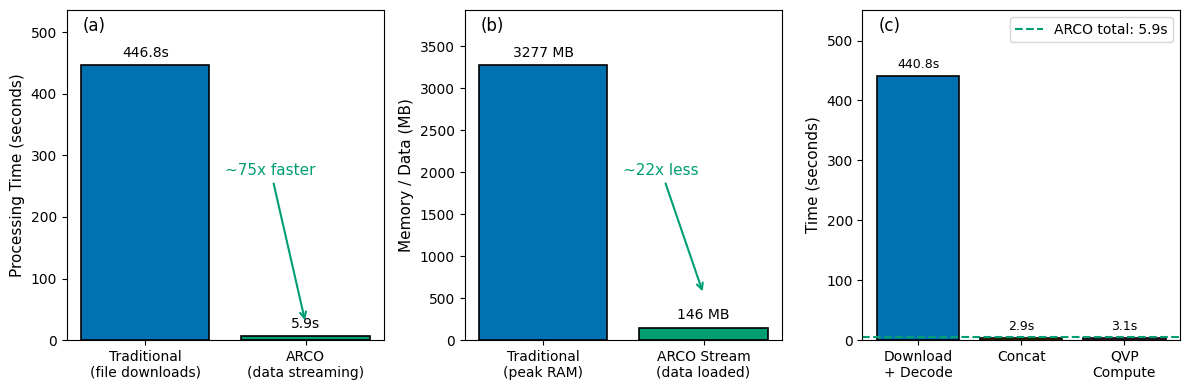

In [17]:
plot_workflow_comparison(
    metrics,
    save_path="workflow_comparison_cleaned.png",
)
plt.show()

---
## Key takeaway

ARCO's advantage isn't compression — it's **selective access**. The traditional path downloads every sweep of every variable in every file (~809 MB compressed, ~3.2 GB decompressed) to extract the 146 MB it actually needs. ARCO streams exactly those 146 MB and nothing else. Once the data model and storage layer make that selectivity declarative — one `.sel(vcp_time=slice(...))` instead of fifty lines of file iteration — the toil Abernathey et al. (2021) describe simply disappears.

The same pattern scales linearly with window length. Notebook 4 picks up here and pushes it from a single 4-hour window to seasonal QPE on a Dask cluster.

---

← **[Notebook 2 — KLOT Low Sweeps](2.KLOT-LowSweeps)** &nbsp; · &nbsp; **[Notebook 4 — QPE Scaling Benchmark →](4.QPE-Scaling-Benchmark)**

## References

* Abernathey, R.P., T. Augspurger, A. Banihirwe, C.C. Blackmon-Luca, T.J. Crone, C.L. Gentemann, J.J. Hamman, N. Henderson, C. Lepore, T.A. McCaie, N.H. Robinson, and R.P. Signell, 2021: Cloud-Native Repositories for Big Scientific Data. *Computing in Science & Engineering*, **23**, 26–35, https://doi.org/10.1109/MCSE.2021.3059437.

* Ryzhkov, A., P. Zhang, H. Reeves, M. Kumjian, T. Tschallener, S. Trömel, and C. Simmer, 2016: Quasi-Vertical Profiles—A New Way to Look at Polarimetric Radar Data. *J. Atmos. Oceanic Technol.*, **33**, 551–562, https://doi.org/10.1175/JTECH-D-15-0020.1.

* Wilkinson, M.D., et al., 2016: The FAIR Guiding Principles for scientific data management and stewardship. *Scientific Data*, **3**, 160018, https://doi.org/10.1038/sdata.2016.18.
* Ladino-Rincón, A., et al. (2026). *Radar DataTree: A FAIR and Cloud-Native Framework for Scalable Weather Radar Archives.* (Manuscript in preparation.)
* Earlier preprint: arXiv:2510.24943, https://doi.org/10.48550/arXiv.2510.24943
